In [1]:
import pandas as pd

df = pd.read_csv("readings.csv")

In [2]:
def load_sessions(paths): # list of file paths
  frames = []
  for p in paths:
        temp_df = pd.read_csv(p)
        temp_df = temp_df.reset_index(drop=True) # Ensure a simple RangeIndex
        temp_df['ts_us'] = temp_df.index * 10000 # Add ts_us to each dataframe assuming 100Hz
        frames.append(temp_df)
  return pd.concat(frames, keys=paths)

In [3]:
combined = load_sessions(["readings.csv"])
combined.shape
combined.index[:3]

MultiIndex([('readings.csv', 0),
            ('readings.csv', 1),
            ('readings.csv', 2)],
           )

In [4]:
def clean(df):
  before = len(df)
  sensors = df[["s0","s1","s2","s3","s4","s5"]]
  ok = ((sensors >= 0) & (sensors <= 4095)).all(axis=1)
  print("dropped:", before - len(df[ok]), "of", before)
  return df[ok]



In [5]:
cleaned = clean(combined)
print(cleaned.shape)

dropped: 0 of 6000
(6000, 8)


In [6]:
import numpy as np
values = cleaned[["s0","s1","s2","s3","s4","s5"]].to_numpy()
print(values.shape)
first = values[0:100, :]
print(first.shape)

(6000, 6)
(100, 6)


In [7]:
def window(values, length, stride):
  n = (len(values) - length) // stride + 1
  out = []
  for k in range(n):
        start = k * stride
        out.append(values[start : start + length, :])
  return np.stack(out)

w = window(values, 100, 50)
print(w.shape)

(119, 100, 6)


In [8]:
sensors = cleaned[["s0","s1","s2","s3","s4","s5"]]

summary = pd.DataFrame({
    "mean": sensors.mean(),
    "peak": sensors.max(),
    "active_frac": (sensors > 100).mean(),
})

print(summary)

          mean  peak  active_frac
s0  469.040833  1951     0.399000
s1  492.813167  1557     0.533167
s2  797.923833  2144     0.600000
s3  822.982167  2251     0.600000
s4  570.437167  1843     0.515667
s5  388.058333  1655     0.382667


In [9]:
toy = cleaned.head(20)
toy.to_csv("toy.csv", index=False)

In [10]:
t = load_sessions(["toy.csv"])
t = clean(t)
tv = t[["s0","s1","s2","s3","s4","s5"]].to_numpy()
tw = window(tv, 5, 5)
print(tw.shape)

dropped: 0 of 20
(4, 5, 6)


In [11]:
import numpy as np
import matplotlib.pyplot as plt

SENSOR_COLS = ["s0", "s1", "s2", "s3", "s4", "s5"]

def plot_session(df, flagged_times=None, title="Session"):
    t_sec = df["ts_us"] / 1e6
    fig, axes = plt.subplots(6, 1, sharex=True, sharey=True, figsize=(11, 9))
    for i, col in enumerate(SENSOR_COLS):
        ax = axes[i]
        ax.plot(t_sec, df[col], linewidth=0.8)
        ax.set_ylabel(col, rotation=0, labelpad=18, va="center")
        ax.grid(alpha=0.3)
        if flagged_times is not None:
            for ft in flagged_times:
                ax.axvline(ft, color="red", linewidth=1.0, alpha=0.7)
    axes[0].set_title(title)
    axes[-1].set_xlabel("time (s)")
    axes[-1].set_ylim(0, 4095)
    fig.tight_layout()
    return fig, axes



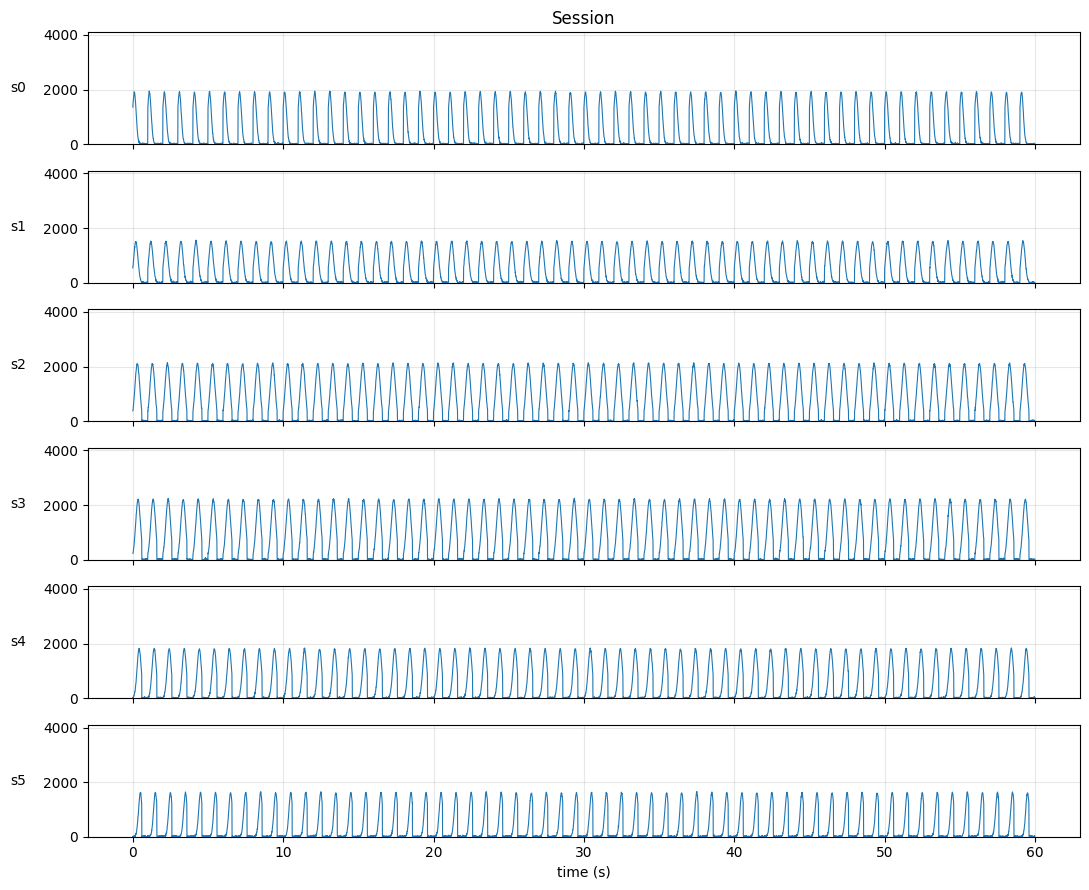

In [12]:
fig, axes = plot_session(cleaned)

In [13]:
T_ON = 2000        # RETUNE
T_OFF = 750        # RETUNE
MIN_DURATION = 30  # RETUNE

def find_stances(total):
    stances = []
    in_stance = False
    start = 0
    for i, x in enumerate(total):
        if in_stance:
            if x < T_OFF:
                if i - start >= MIN_DURATION:
                    stances.append((start, i - 1))
                in_stance = False
        else:
            if x >= T_ON:
                start = i
                in_stance = True
    return stances

In [14]:
def plot_stances(t_sec, total, stances, xlim=None, title="Detected stances"):
    fig, ax = plt.subplots(1, 1, figsize=(11, 4))
    for (a, b) in stances:
        ax.axvspan(t_sec[a], t_sec[b], color="#1D9E75", alpha=0.18, linewidth=0)
    ax.plot(t_sec, total, linewidth=0.9, color="#378ADD")
    ax.axhline(T_ON, color="#888780", linestyle="--", linewidth=0.8)
    ax.axhline(T_OFF, color="#888780", linestyle=":", linewidth=0.8)
    ax.text(t_sec[0], T_ON, " T_ON", va="bottom", fontsize=8, color="#666")
    ax.text(t_sec[0], T_OFF, " T_OFF", va="bottom", fontsize=8, color="#666")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("total force (ADC counts)")
    ax.set_title(f"{title} - {len(stances)} stances")
    ax.grid(alpha=0.3)
    if xlim is not None:
        ax.set_xlim(*xlim)
    fig.tight_layout()
    return fig, ax

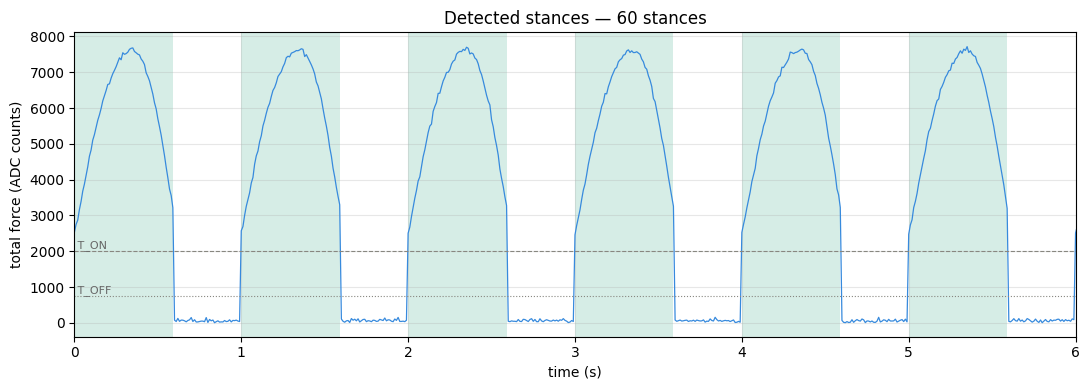

In [15]:
t_sec = (cleaned["ts_us"] / 1e6).to_numpy()
total = values.sum(axis=1)
stances = find_stances(total)
fig, ax = plot_stances(t_sec, total, stances, xlim=(0, 6))

In [16]:
def overlap(x, y):
    return max(0, min(x[1], y[1]) - max(x[0], y[0]) + 1)

def match_stances(detected, truth, min_overlap=0.5):
    claimed = set()
    tp = 0
    for d in detected:
        best, best_ov = None, 0
        for j, t in enumerate(truth):
            if j in claimed:
                continue
            ov = overlap(d, t)
            if ov > best_ov:
                best, best_ov = j, ov
        if best is not None and best_ov >= min_overlap * (truth[best][1] - truth[best][0] + 1):
            claimed.add(best)
            tp += 1
    fp = len(detected) - tp
    fn = len(truth) - tp
    return tp, fp, fn

def precision_recall(tp, fp, fn):
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    return p, r


In [17]:
SENSOR_COLS =  ["s0", "s1", "s2", "s3", "s4", "s5"]
# RETUNE coordinates to match actual placements [Where y increases away from the heel and x increases moving right from the heel]
SENSOR_COORDS = {
  "s0" : (0.35, 0.10),
  "s1" : (0.65, 0.10),
  "s2" : (0.30, 0.55),
  "s3" : (0.70, 0.55),
  "s4" : (0.35, 0.90),
  "s5" : (0.70, 0.90),
}



In [18]:
def frame_dt(ts_us):
    return ts_us.diff().median() / 1_000_000.0

In [19]:
def stance_features(total, dt, start, end):
    seg = np.asarray(total)[start:end]

    peak_idx = int(np.argmax(seg))
    peak_counts = float(seg[peak_idx])
    time_to_peak_s = peak_idx * dt
    contact_time_s = (end - start) * dt
    impulse_counts_s = float(seg.sum()) * dt

    if time_to_peak_s > 0:
        loading_rate_cps = (peak_counts - float(seg[0])) / time_to_peak_s
    else:
        loading_rate_cps = np.nan

    return {
        "peak_counts": peak_counts,
        "time_to_peak_s": time_to_peak_s,
        "contact_time_s": contact_time_s,
        "loading_rate_cps": loading_rate_cps,
        "impulse_counts_s": impulse_counts_s,
    }

In [20]:
def cop_frame(row):

  total_weight = sum(row[name] for name in SENSOR_COLS)
  if total_weight == 0:
    return (np.nan,np.nan)

  cop_x = 0.0
  cop_y = 0.0

  for name in SENSOR_COLS:
      x, y = SENSOR_COORDS[name]
      cop_x += row[name]*x
      cop_y += row[name]*y

  cop_x /= total_weight
  cop_y /= total_weight

  return (cop_x, cop_y)

In [21]:
def cop_trajectory(df, start, end):
  ls = []
  for _, row in df.iloc[start:end].iterrows():
    ls.append(cop_frame(row))
  return np.array(ls)



In [22]:
def cop_features(traj):
    NAN_RESULT = {"cop_path_len": np.nan, "cop_displacement": np.nan}

    valid = [(x, y) for x, y in traj if not (np.isnan(x) or np.isnan(y))]
    if len(valid) < 2:
        return NAN_RESULT

    path_len = 0.0
    for i in range(len(valid) - 1):
        x0, y0 = valid[i]
        x1, y1 = valid[i + 1]
        path_len += np.hypot(x1 - x0, y1 - y0)

    x_first, y_first = valid[0]
    x_last, y_last = valid[-1]
    displacement = np.hypot(x_last - x_first, y_last - y_first)

    return {"cop_path_len": path_len, "cop_displacement": displacement}

In [23]:
def extract_features(df, stances, label):

  if len(stances) == 0:
    return pd.DataFrame([])

  dt = frame_dt(df["ts_us"])
  total = df[SENSOR_COLS].sum(axis=1)
  rows = []

  for start, end in stances:
    stance_ft = stance_features(total, dt, start, end)
    cop_traj = cop_trajectory(df, start, end)
    cop_ft = cop_features(cop_traj)

    row = {**stance_ft, **cop_ft, "start": start, "end": end, "label": label}
    rows.append(row)

  return pd.DataFrame(rows)



In [24]:
feat = extract_features(df, stances, "walk")
feat.to_csv("readings.csv", index=False)